In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Data transformations
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

#Data Downloading
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 510kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.56MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.94MB/s]


In [4]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model_sgd  = SimpleMLP()
model_adam = SimpleMLP()

In [5]:
optimizer_sgd  = optim.SGD(model_sgd.parameters(), lr=0.01)
optimizer_adam = optim.Adam(model_adam.parameters(), lr=0.001)

criterion = nn.CrossEntropyLoss()

In [6]:
def train(model, optimizer, loader, epochs=5):
    loss_history = []
    for epoch in range(epochs):
        for data, target in loader:
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            loss_history.append(loss.item())
    return loss_history

loss_sgd  = train(model_sgd, optimizer_sgd, train_loader)
loss_adam = train(model_adam, optimizer_adam, train_loader)

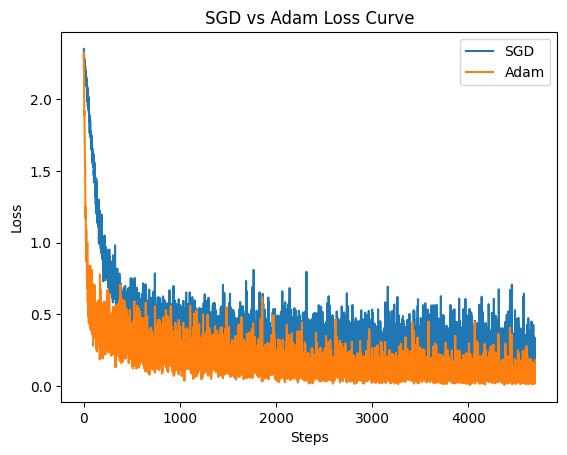

In [7]:
plt.plot(loss_sgd, label="SGD")
plt.plot(loss_adam, label="Adam")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("SGD vs Adam Loss Curve")
plt.legend()
plt.show()

In [8]:
def evaluate(model, loader):
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in loader:
            output = model(data)
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    return correct / total

acc_sgd  = evaluate(model_sgd, test_loader)
acc_adam = evaluate(model_adam, test_loader)

print(f"SGD Accuracy: {acc_sgd*100:.2f}%")
print(f"Adam Accuracy: {acc_adam*100:.2f}%")

SGD Accuracy: 92.57%
Adam Accuracy: 97.03%


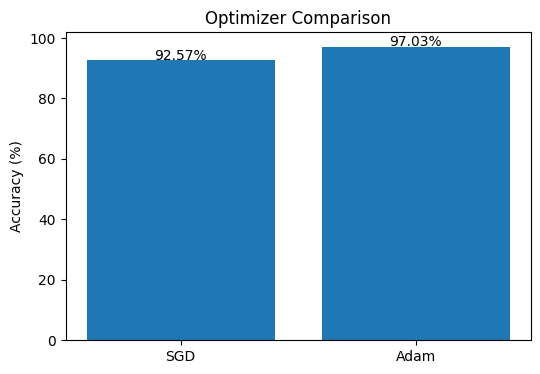

In [10]:
plt.figure(figsize=(6,4))

plt.bar(optimizers, accuracies)

for i,v in enumerate(accuracies):
    plt.text(i, v+0.2, f"{v:.2f}%", ha='center')

plt.ylabel("Accuracy (%)")
plt.title("Optimizer Comparison")

plt.show()